# **PyTorch in One Hour: From Tensors to Training Neural Networks on Multiple GPUs**
## This notebook reproduces the code and results from the blog https://sebastianraschka.com/teaching/pytorch-1h/ by Sebastian Raschka

# Installing PyTorch

In [ ]:
# Installing PyTorch
# ! pip install torch==2.4.1

In [ ]:
# To check the version of PyTorch
import torch
print(torch.__version__)

2.6.0+cu124


In [ ]:
# To check whether your installation recognizes your built-in NVIDIA GPU by running the following code in Python
torch.cuda.is_available()

True

# Understanding tensors
PyTorch tensors are data containers for array-like structures. A scalar is a 0-dimensional tensor (for instance, just a number), a vector is a 1-dimensional tensor, and a matrix is a 2-dimensional tensor.

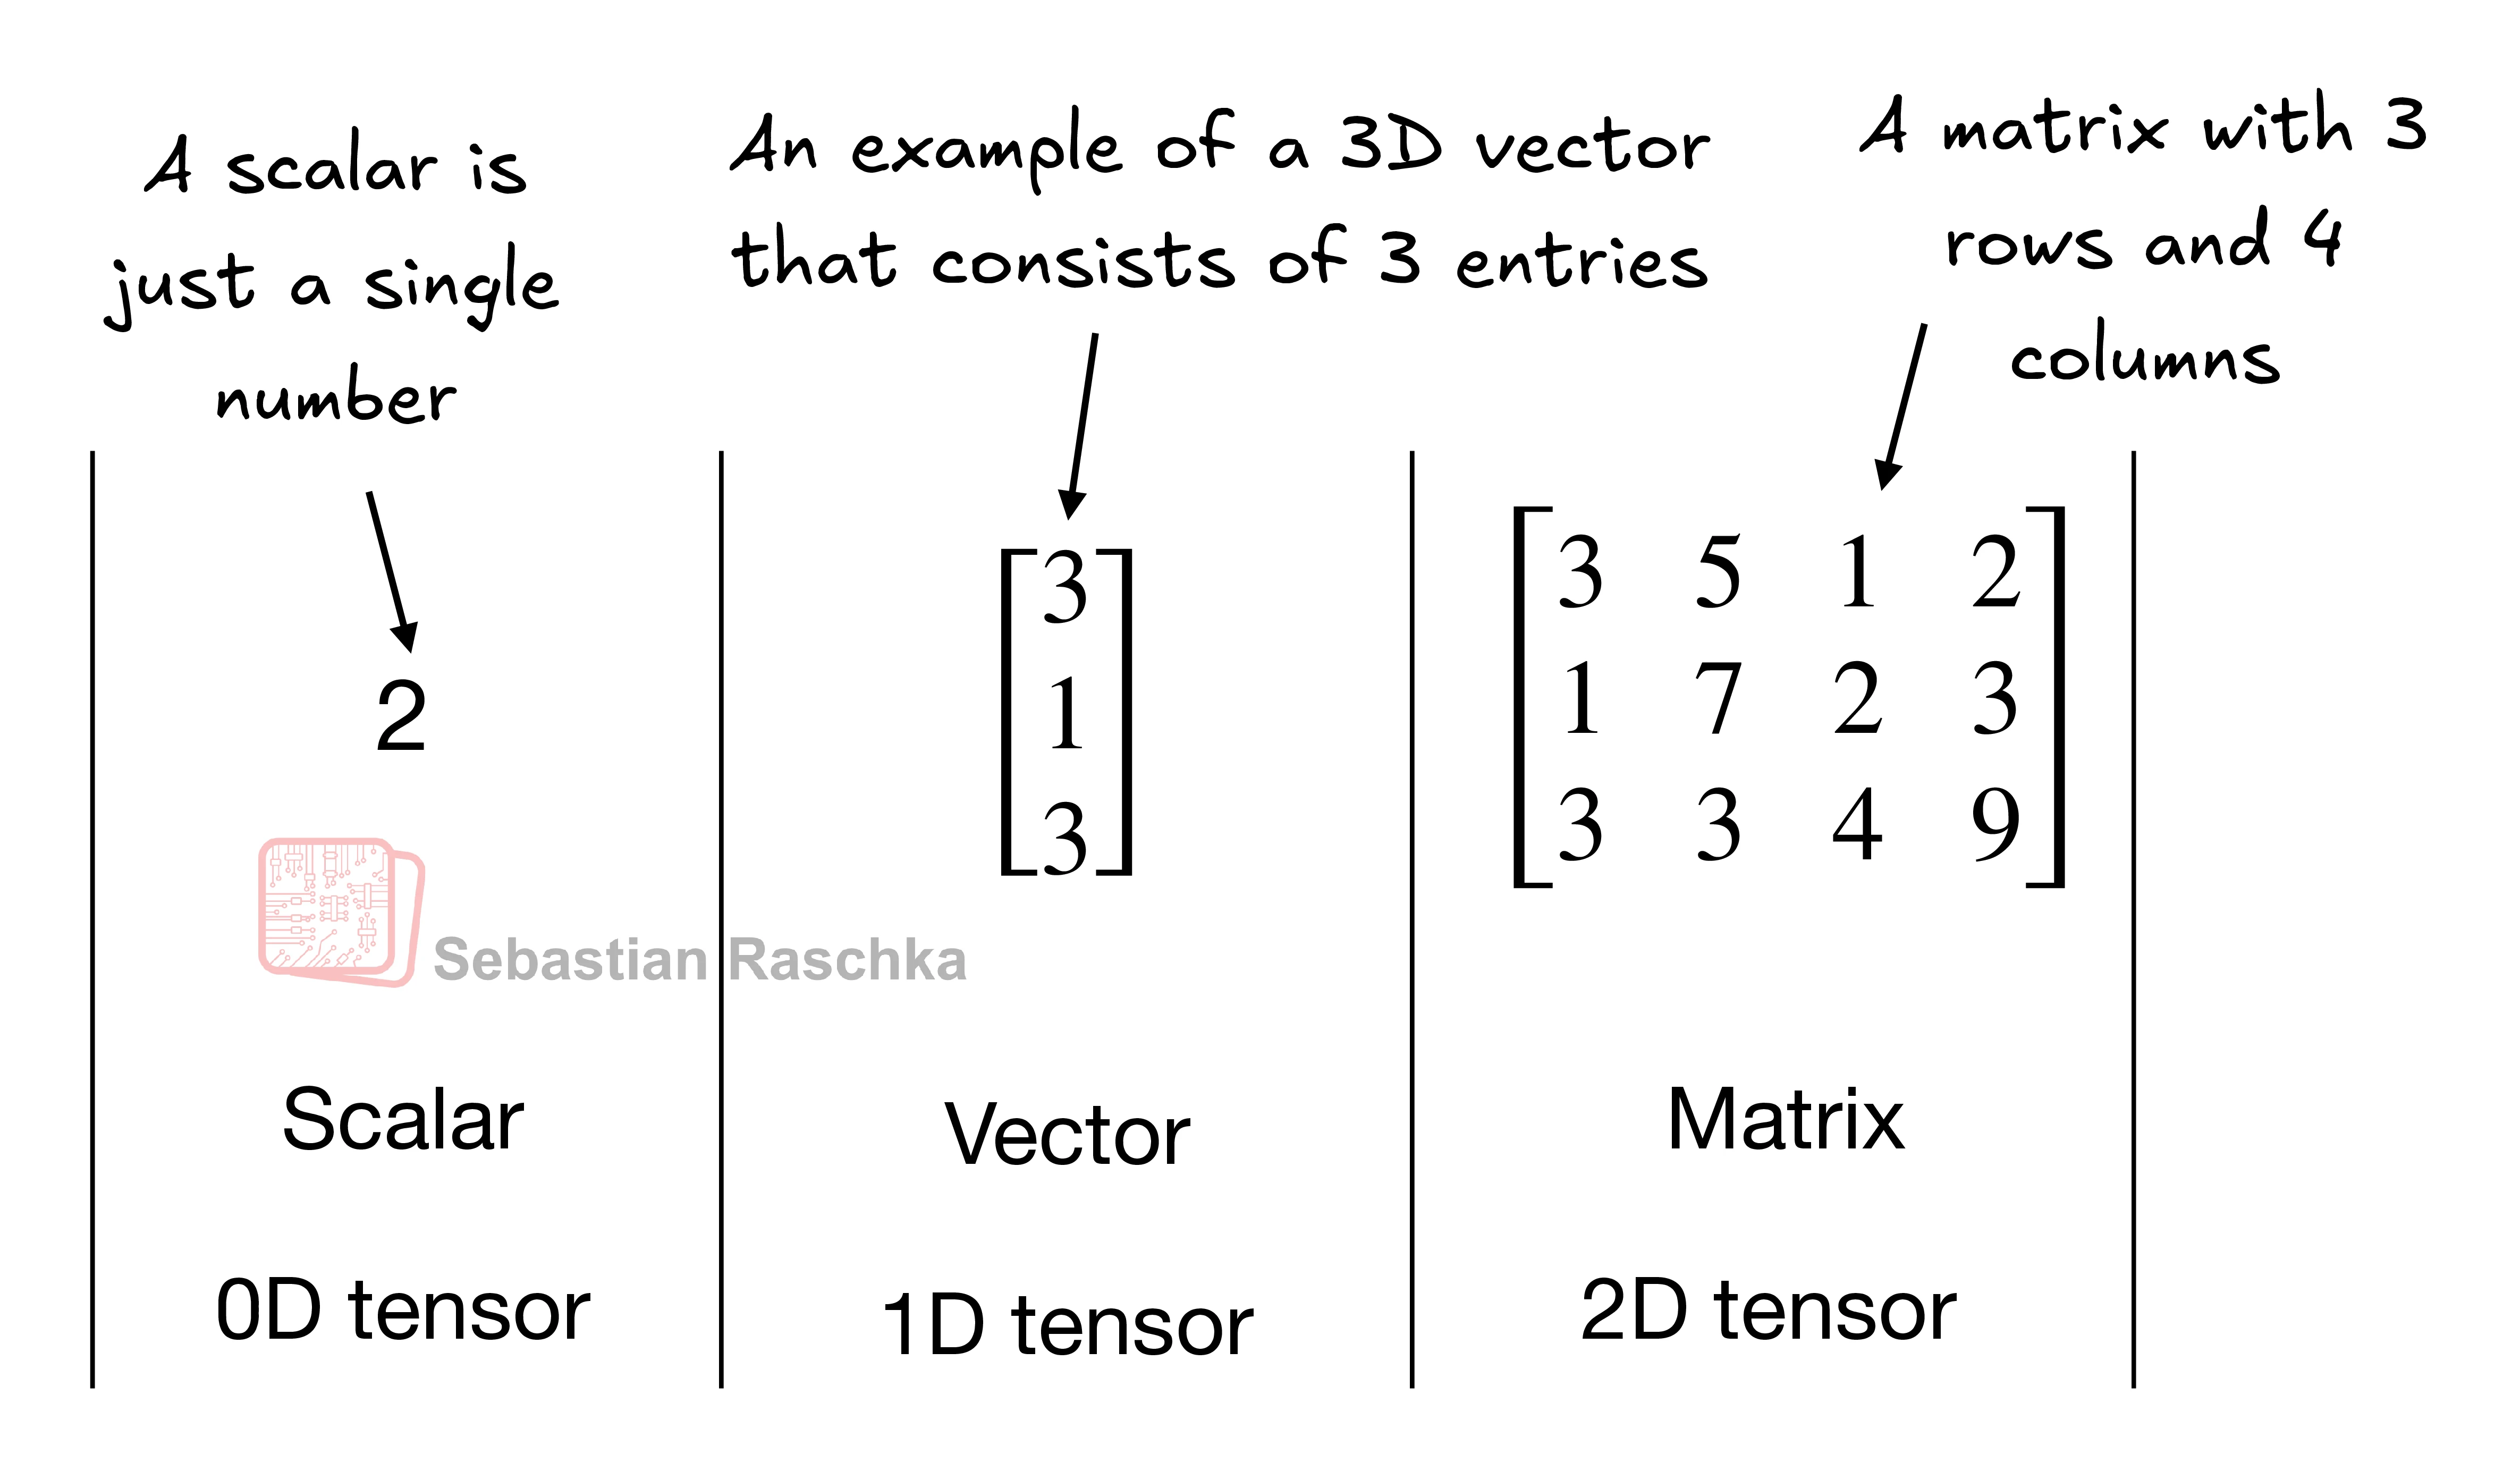

In [ ]:
# We can create objects of PyTorch’s Tensor class using the torch.tensor function as follows:

tensor0d = torch.tensor(1)
print('0D tensor: ', tensor0d)

tensor1d = torch.tensor([1,2,3])
print('1D tensor: ', tensor1d)

tensor2d = torch.tensor([[1, 2], [3, 4]])
print('2D tensor: \n', tensor2d)

tensor3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print('3D tensor: \n', tensor3d)

0D tensor:  tensor(1)
1D tensor:  tensor([1, 2, 3])
2D tensor: 
 tensor([[1, 2],
        [3, 4]])
3D tensor: 
 tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])


In [ ]:
# We can access the data type of a tensor via the .dtype attribute of a tensor
print('Data type of tensor:', tensor0d.dtype)
print('For 3D tensor      :', tensor3d.dtype)


Data type of tensor: torch.int64
For 3D tensor      : torch.int64


In [ ]:
# If we create tensors from Python floats, PyTorch creates tensors with a 32-bit precision by default, as we can see below:
float_tensor = torch.tensor([0.1, 1.0, 2])
print(float_tensor.dtype)

torch.float32


In [ ]:
# It is possible to readily change the precision using a tensor’s .to method.
# The following code demonstrates this by changing a 64-bit integer tensor into a 32-bit float tensor
change_to_float_tensor = tensor1d.to(torch.float32)
print(change_to_float_tensor.dtype)

torch.float32


In [ ]:
tensor2d_new = torch.tensor([[2, 3, 4],[5, 6, 7]])
print(tensor2d_new)

tensor([[2, 3, 4],
        [5, 6, 7]])


In [ ]:
# The .shape attribute allows us to access the shape of a tensor:
print(tensor3d.shape)
print(tensor2d.shape)
print(tensor2d_new.shape)

torch.Size([2, 2, 2])
torch.Size([2, 2])
torch.Size([2, 3])


In [ ]:
# To reshape the tensor into a 3 by 2 tensor, we can use the .reshape method:
print(tensor2d_new.reshape(3, 2))


tensor([[2, 3],
        [4, 5],
        [6, 7]])


In [ ]:
# However, note that the more common command for reshaping tensors in PyTorch is .view():
print(tensor2d_new.view(3, 2))

tensor([[2, 3],
        [4, 5],
        [6, 7]])


In [ ]:
# We can use .T to transpose a tensor, which means flipping it across its diagonal
print(tensor2d_new.T)

tensor([[2, 5],
        [3, 6],
        [4, 7]])


In [ ]:
print(tensor2d_new.T.T)

tensor([[2, 3, 4],
        [5, 6, 7]])


In [ ]:
# Common way to multiply two matrices in PyTorch is the .matmul method:
print(tensor2d_new.matmul(tensor2d_new.T))

tensor([[ 29,  56],
        [ 56, 110]])


In [ ]:
print(tensor3d.matmul(tensor3d.T))

tensor([[[  7,  19],
         [ 15,  43]],

        [[ 34,  78],
         [ 46, 106]]])


/tmp/ipython-input-16-3109003337.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  print(tensor3d.matmul(tensor3d.T))


In [ ]:
# We can also adopt the @ operator, which accomplishes the same thing more compactly
print(tensor2d@tensor2d.T)

tensor([[ 5, 11],
        [11, 25]])


# Seeing models as computation graph

In [ ]:
# a simple logistic regression classifier, which can be seen as a single-layer neural network, returning a score between 0 and 1
# that is compared to the true class label (0 or 1) when computing the loss:

import torch.nn.functional as F

y = torch.tensor([1.0])  # true label
x1 = torch.tensor([1.1]) # input feature
w1 = torch.tensor([2.2]) # weight parameter
b = torch.tensor([.0])  # bias unit

z = x1 * w1 + b          # net input
a = torch.sigmoid(z)     # activation & output

loss = F.binary_cross_entropy(a, y)
print(loss)

tensor(0.0852)


# Automatic differentiation made easy
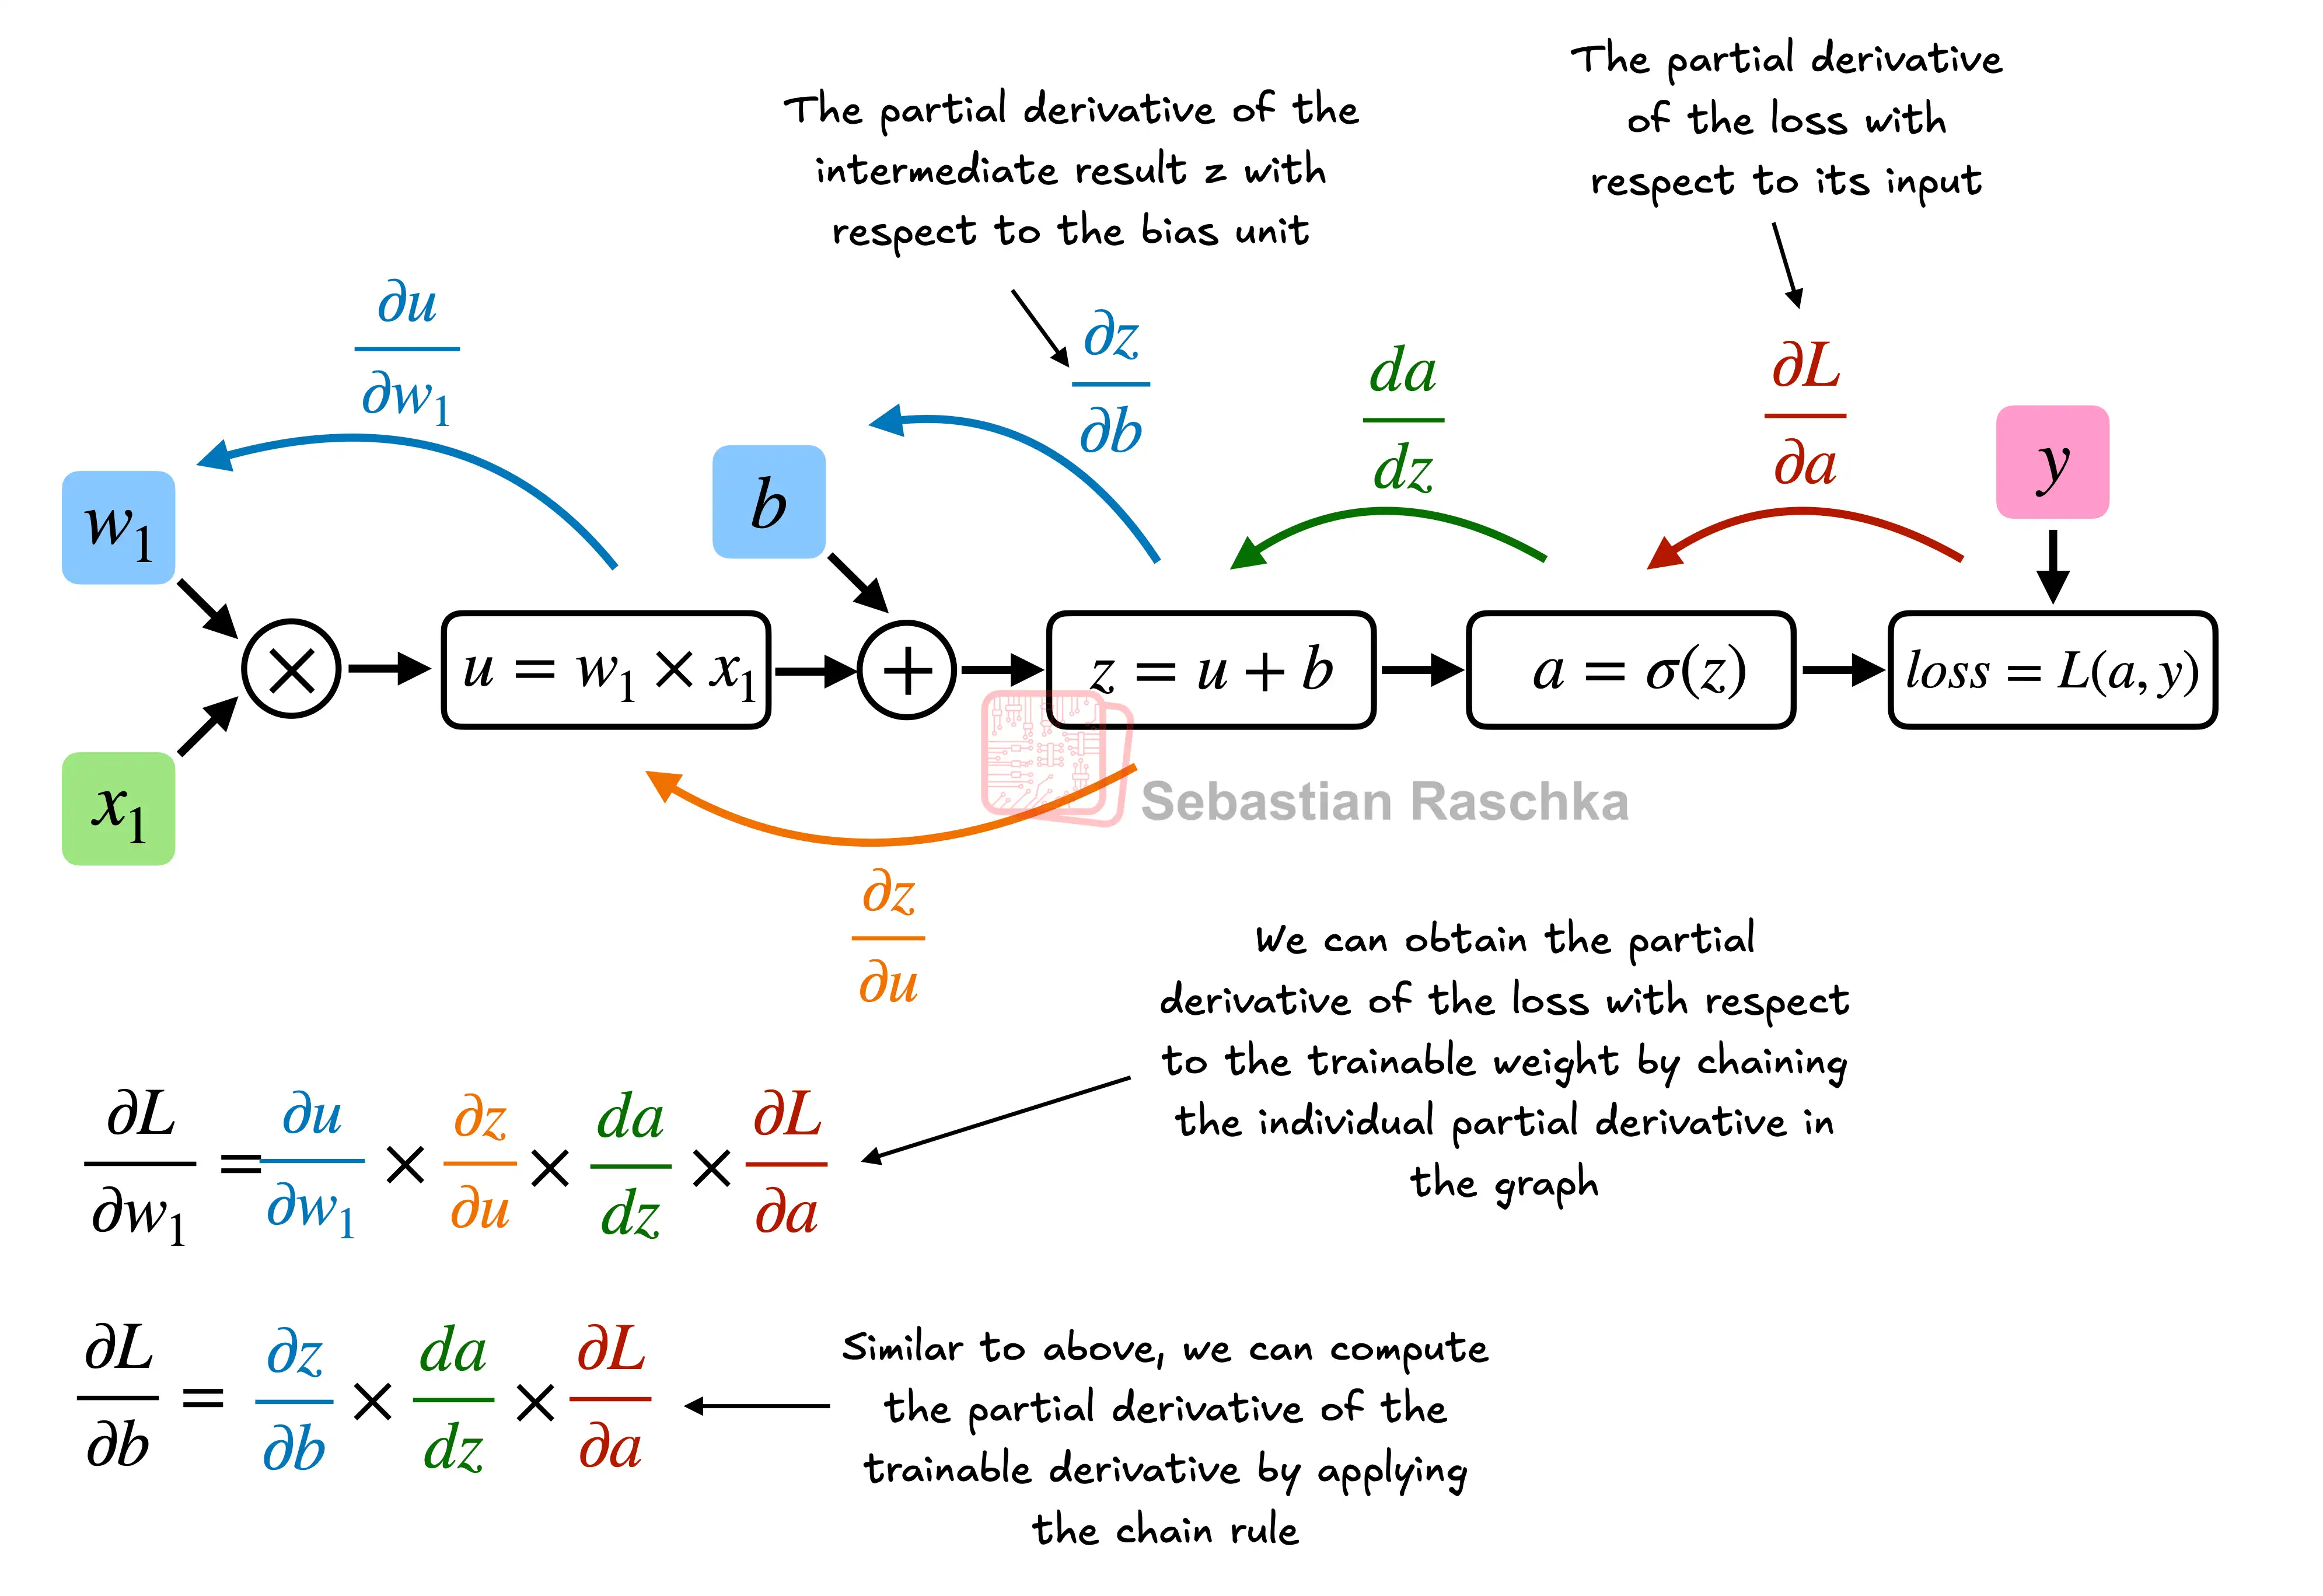

In [ ]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)

In [ ]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


# Implementing multilayer neural networks

When implementing a neural network in PyTorch, we typically use a subclass of **torch.nn.Module** class to define our own custom network architecture.
This Module base class provides a lot of functionality, making it easier to build and train models.
For instance, it allows us to encapsulate layers and operations and keep track of the model’s parameters.

Within this subclass, we define the network layers in the **__init__** constructor and specify how they interact in the forward method.
The forward method describes how the input data passes through the network and comes together as a computation graph.

In contrast, the backward method, which we typically do not need to implement ourselves,
is used during training to compute gradients of the loss function with respect to the model parameters


In [ ]:
# The following code implements a classic multilayer perceptron with two hidden layers to illustrate a typical usage of the Module class:

class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

In [ ]:
# We can then instantiate a new neural network object as follows:

model = NeuralNetwork(50, 3)

In [ ]:
# We can then instantiate a new neural network object as follows:

print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


In [ ]:
help(torch.nn.functional)

Help on module torch.nn.functional in torch.nn:

NAME
    torch.nn.functional - Functional interface.

FUNCTIONS
    adaptive_avg_pool1d(...)
        adaptive_avg_pool1d(input, output_size) -> Tensor
        
        Applies a 1D adaptive average pooling over an input signal composed of
        several input planes.
        
        See :class:`~torch.nn.AdaptiveAvgPool1d` for details and output shape.
        
        Args:
            output_size: the target output size (single integer)
    
    adaptive_avg_pool2d(input: torch.Tensor, output_size: None) -> torch.Tensor
        Apply a 2D adaptive average pooling over an input signal composed of several input planes.
        
        See :class:`~torch.nn.AdaptiveAvgPool2d` for details and output shape.
        
        Args:
            output_size: the target output size (single integer or
                double-integer tuple)
    
    adaptive_avg_pool3d(input: torch.Tensor, output_size: None) -> torch.Tensor
        Apply a 3D ad

In [ ]:
help(NeuralNetwork)

Help on class NeuralNetwork in module __main__:

class NeuralNetwork(torch.nn.modules.module.Module)
 |  NeuralNetwork(num_inputs, num_outputs)
 |  
 |  Method resolution order:
 |      NeuralNetwork
 |      torch.nn.modules.module.Module
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, num_inputs, num_outputs)
 |      Initialize internal Module state, shared by both nn.Module and ScriptModule.
 |  
 |  forward(self, x)
 |      Define the computation performed at every call.
 |      
 |      Should be overridden by all subclasses.
 |      
 |      .. note::
 |          Although the recipe for forward pass needs to be defined within
 |          this function, one should call the :class:`Module` instance afterwards
 |          instead of this since the former takes care of running the
 |          registered hooks while the latter silently ignores them.
 |  
 |  ----------------------------------------------------------------------
 |  Data and other attribut

In [ ]:
help(torch.autograd )

Help on package torch.autograd in torch:

NAME
    torch.autograd - ``torch.autograd`` provides classes and functions implementing automatic differentiation of arbitrary scalar valued functions.

DESCRIPTION
    It requires minimal changes to the existing code - you only need to declare :class:`Tensor` s
    for which gradients should be computed with the ``requires_grad=True`` keyword.
    As of now, we only support autograd for floating point :class:`Tensor` types (
    half, float, double and bfloat16) and complex :class:`Tensor` types (cfloat, cdouble).

PACKAGE CONTENTS
    _functions (package)
    anomaly_mode
    forward_ad
    function
    functional
    grad_mode
    gradcheck
    graph
    profiler
    profiler_legacy
    profiler_util
    variable

CLASSES
    builtins.object
        torch.autograd.anomaly_mode.detect_anomaly
        torch.autograd.anomaly_mode.set_detect_anomaly
    torch._C._LegacyVariableBase(builtins.object)
        torch.autograd.variable.Variable
    t

In [ ]:
# Next, let’s check the total number of trainable parameters of this model:

num_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


In [ ]:
# Based on the print(model) call we executed above, we can see that the first Linear layer is at index position 0 in the layers attribute.
# We can access the corresponding weight parameter matrix as follows:

print(model.layers[0].weight)

Parameter containing:
tensor([[ 0.1353, -0.0982, -0.0349,  ...,  0.0640, -0.0459,  0.0273],
        [-0.0558,  0.0639,  0.0412,  ..., -0.0959, -0.0464,  0.1004],
        [ 0.1094, -0.0212,  0.0005,  ...,  0.0865, -0.1338, -0.0429],
        ...,
        [-0.0538,  0.1057, -0.0198,  ..., -0.0740, -0.0955, -0.1295],
        [-0.0293,  0.1208,  0.1152,  ..., -0.0841, -0.0186,  0.1077],
        [-0.1307,  0.0195,  0.0653,  ...,  0.0946, -0.0735, -0.0134]],
       requires_grad=True)


In [ ]:
print(model.layers[0].weight.shape)

torch.Size([30, 50])


In [ ]:
print(model.layers[0].bias)

Parameter containing:
tensor([ 0.0498, -0.0606,  0.0883, -0.0765,  0.0780,  0.0426,  0.1304, -0.0068,
        -0.0015, -0.1066, -0.1106, -0.1156,  0.1026, -0.0082,  0.0786, -0.1223,
        -0.0625, -0.0061,  0.0847,  0.0793,  0.1015, -0.0279,  0.0875, -0.1288,
        -0.0448,  0.0953, -0.1311, -0.0626, -0.1126,  0.0975],
       requires_grad=True)


In [ ]:
print(model.layers[0].bias.shape)

torch.Size([30])


In [ ]:
#  we can make the random number initialization reproducible by seeding PyTorch’s random number generator via manual_seed:

torch.manual_seed(42)

model = NeuralNetwork(50, 3)
print(model.layers[0].weight)

Parameter containing:
tensor([[ 0.1081,  0.1174, -0.0331,  ...,  0.0253,  0.0718, -0.0862],
        [-0.1400, -0.0546, -0.1085,  ..., -0.0477, -0.0501, -0.1368],
        [-0.0810,  0.0353, -0.0187,  ...,  0.1142,  0.1288, -0.1121],
        ...,
        [-0.0031, -0.0573,  0.0515,  ...,  0.0271, -0.0928, -0.1175],
        [-0.0444, -0.1318, -0.0660,  ...,  0.0647, -0.1230, -0.0531],
        [ 0.0023, -0.1223,  0.0797,  ...,  0.0369,  0.0862,  0.1328]],
       requires_grad=True)


In [ ]:
#  Let’s briefly see how it’s used via the forward pass:
torch.manual_seed(42)

x = torch.rand((1,50)) # single random training example X as a toy input (note that our network expects 50-dimensional feature vectors)
out = model(x)
print(out)

tensor([[ 0.1215, -0.0497, -0.1536]], grad_fn=<AddmmBackward0>)


In [ ]:
# So, when we use a model for inference (for instance, making predictions) rather than training,
# it is a best practice to use the torch.no_grad() context manager, as shown below. This tells
# PyTorch that it doesn’t need to keep track of the gradients, which can result in significant
# savings in memory and computation.

with torch.no_grad():
    out = model(x)
print(out)

tensor([[ 0.1215, -0.0497, -0.1536]])


In [ ]:
# In PyTorch, it’s common practice to code models such that they return the outputs of the last layer without passing them to a nonlinear activation function
# To get the class membership probabilities
with torch.no_grad():
    out = torch.softmax(model(x), dim=1)
print(out)

tensor([[0.3843, 0.3238, 0.2919]])


# Setting up efficient data loaders

The overall idea behind data loading in PyTorch is illustrated in figure:
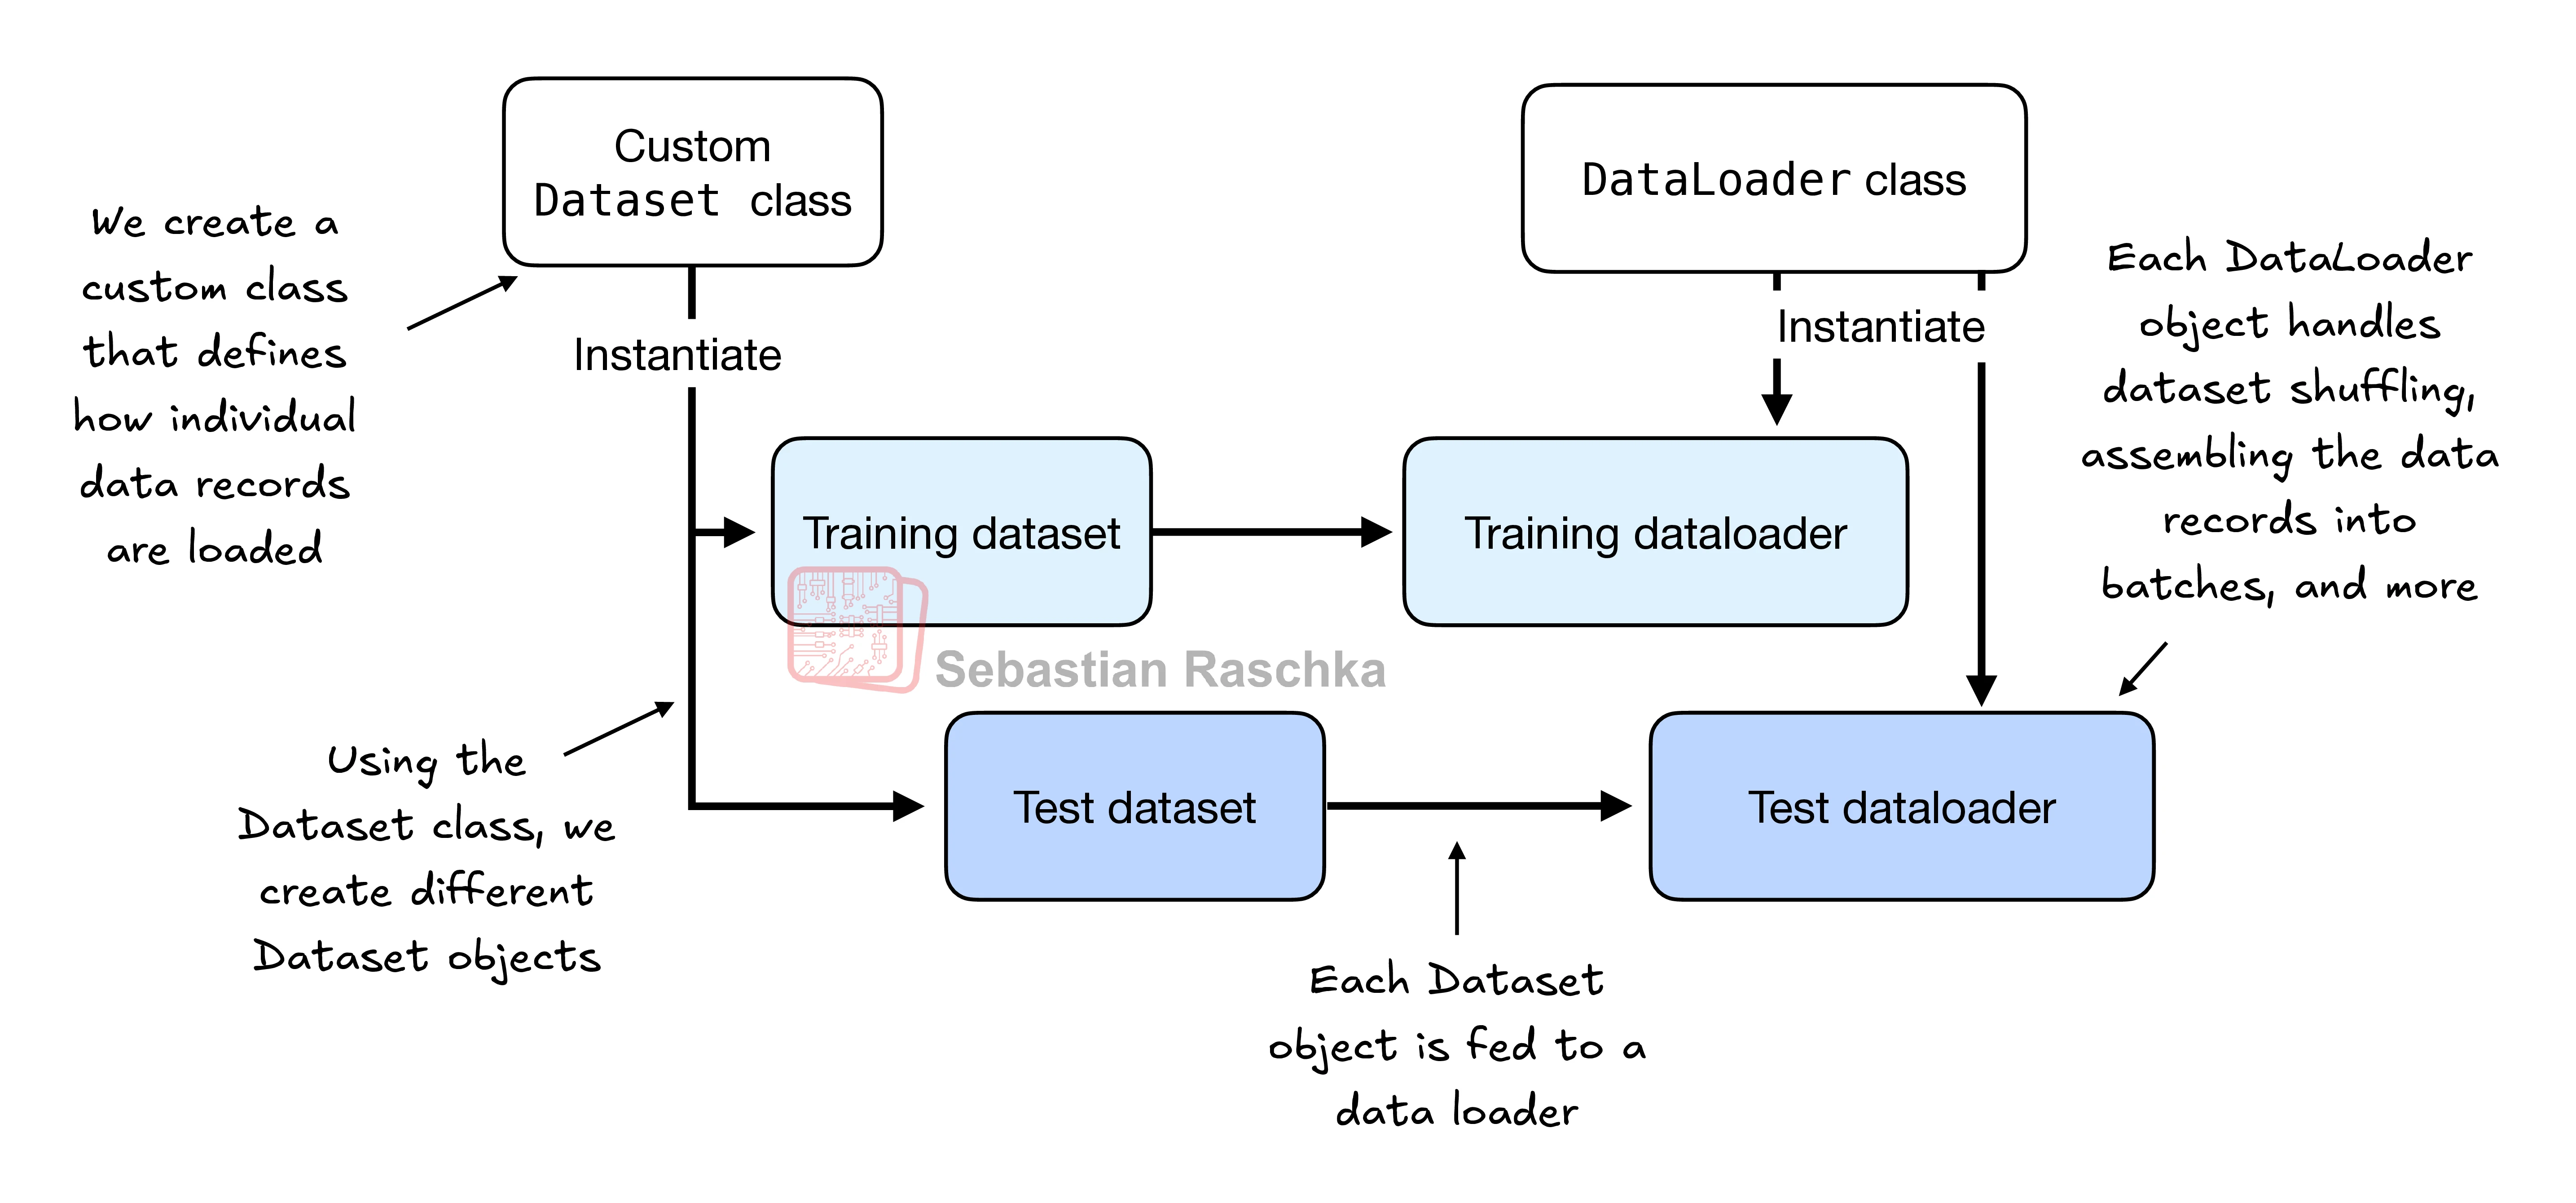

PyTorch implements a `Dataset` and a `DataLoader` class. The `Dataset` class is used to instantiate objects that define how each data record is loaded. The `DataLoader` handles how the data is shuffled and assembled into batches.

In [ ]:
# Let’s start by creating a simple toy dataset of five training examples with two features each.
# Accompanying the training examples, we also create a tensor containing the corresponding class labels:
# three examples belong to class 0, and two examples belong to class 1.
# In addition, we also make a test set consisting of two entries.

x_train = torch.tensor([[-1.2, 3.1],
                       [-0.9, 2.9],
                       [-0.5, 2.6],
                       [2.3, -1.1],
                       [2.7, -1.5]])

y_train = torch.tensor([0, 0, 0, 1, 1])

In [ ]:
x_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])

y_test = torch.tensor([0, 1])

In [ ]:
from torch.utils.data import Dataset

help(Dataset)

Help on class Dataset in module torch.utils.data.dataset:

class Dataset(typing.Generic)
 |  An abstract class representing a :class:`Dataset`.
 |  
 |  All datasets that represent a map from keys to data samples should subclass
 |  it. All subclasses should overwrite :meth:`__getitem__`, supporting fetching a
 |  data sample for a given key. Subclasses could also optionally overwrite
 |  :meth:`__len__`, which is expected to return the size of the dataset by many
 |  :class:`~torch.utils.data.Sampler` implementations and the default options
 |  of :class:`~torch.utils.data.DataLoader`. Subclasses could also
 |  optionally implement :meth:`__getitems__`, for speedup batched samples
 |  loading. This method accepts list of indices of samples of batch and returns
 |  list of samples.
 |  
 |  .. note::
 |    :class:`~torch.utils.data.DataLoader` by default constructs an index
 |    sampler that yields integral indices.  To make it work with a map-style
 |    dataset with non-integral ind

In [ ]:
# reate a custom dataset class, ToyDataset, by subclassing from PyTorch’s Dataset parent class, as shown below

from torch.utils.data import Dataset


class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]

train_ds = ToyDataset(x_train, y_train)
test_ds = ToyDataset(x_test, y_test)

In [ ]:
print(train_ds)
print(test_ds)

In [ ]:
print(train_ds[0])
print(test_ds[1])

(tensor([-1.2000,  3.1000]), tensor(0))
(tensor([ 2.6000, -1.6000]), tensor(1))


In [ ]:
print(len(train_ds))
print(len(test_ds))

5
2


In [ ]:
# Now that we defined a PyTorch Dataset class we can use for our toy dataset,
# we can use PyTorch’s DataLoader class to sample from it, as shown in the code below:

from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [ ]:
# After instantiating the training data loader, we can iterate over it as shown below.

for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3: tensor([[ 2.7000, -1.5000]]) tensor([1])


As we can see based on the output above, the train_loader iterates over the training dataset visiting each training example exactly once. This is known as a training epoch. Since we seeded the random number generator using torch.manual_seed(123) above, you should get the exact same shuffling order of training examples as shown above. However if you iterate over the dataset a second time, you will see that the shuffling order will change. This is desired to prevent deep neural networks getting caught in repetitive update cycles during training.

Note that we specified a batch size of 2 above, but the 3rd batch only contains a single example. That’s because we have five training examples, which is not evenly divisible by 2. In practice, having a substantially smaller batch as the last batch in a training epoch can disturb the convergence during training. To prevent this, it’s recommended to set `drop_last=True`, which will drop the last batch in each epoch, as shown below:

In [ ]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 2: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])


In [ ]:
for idx, (x, y) in enumerate(test_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[-0.8000,  2.8000],
        [ 2.6000, -1.6000]]) tensor([0, 1])


Lastly, let’s discuss the setting `num_workers=0` in the DataLoader. This parameter in PyTorch’s `DataLoader` function is crucial for parallelizing data loading and preprocessing. When num_workers is set to 0, the data loading will be done in the main process and not in separate worker processes. This might seem unproblematic, but it can lead to significant slowdowns during model training when we train larger networks on a GPU. This is because instead of focusing solely on the processing of the deep learning model, the CPU must also take time to load and preprocess the data. As a result, the GPU can sit idle while waiting for the CPU to finish these tasks. In contrast, when num_workers is set to a number greater than zero, multiple worker processes are launched to load data in parallel, freeing the main process to focus on training your model and better utilizing your system’s resources, which is illustrated in figure





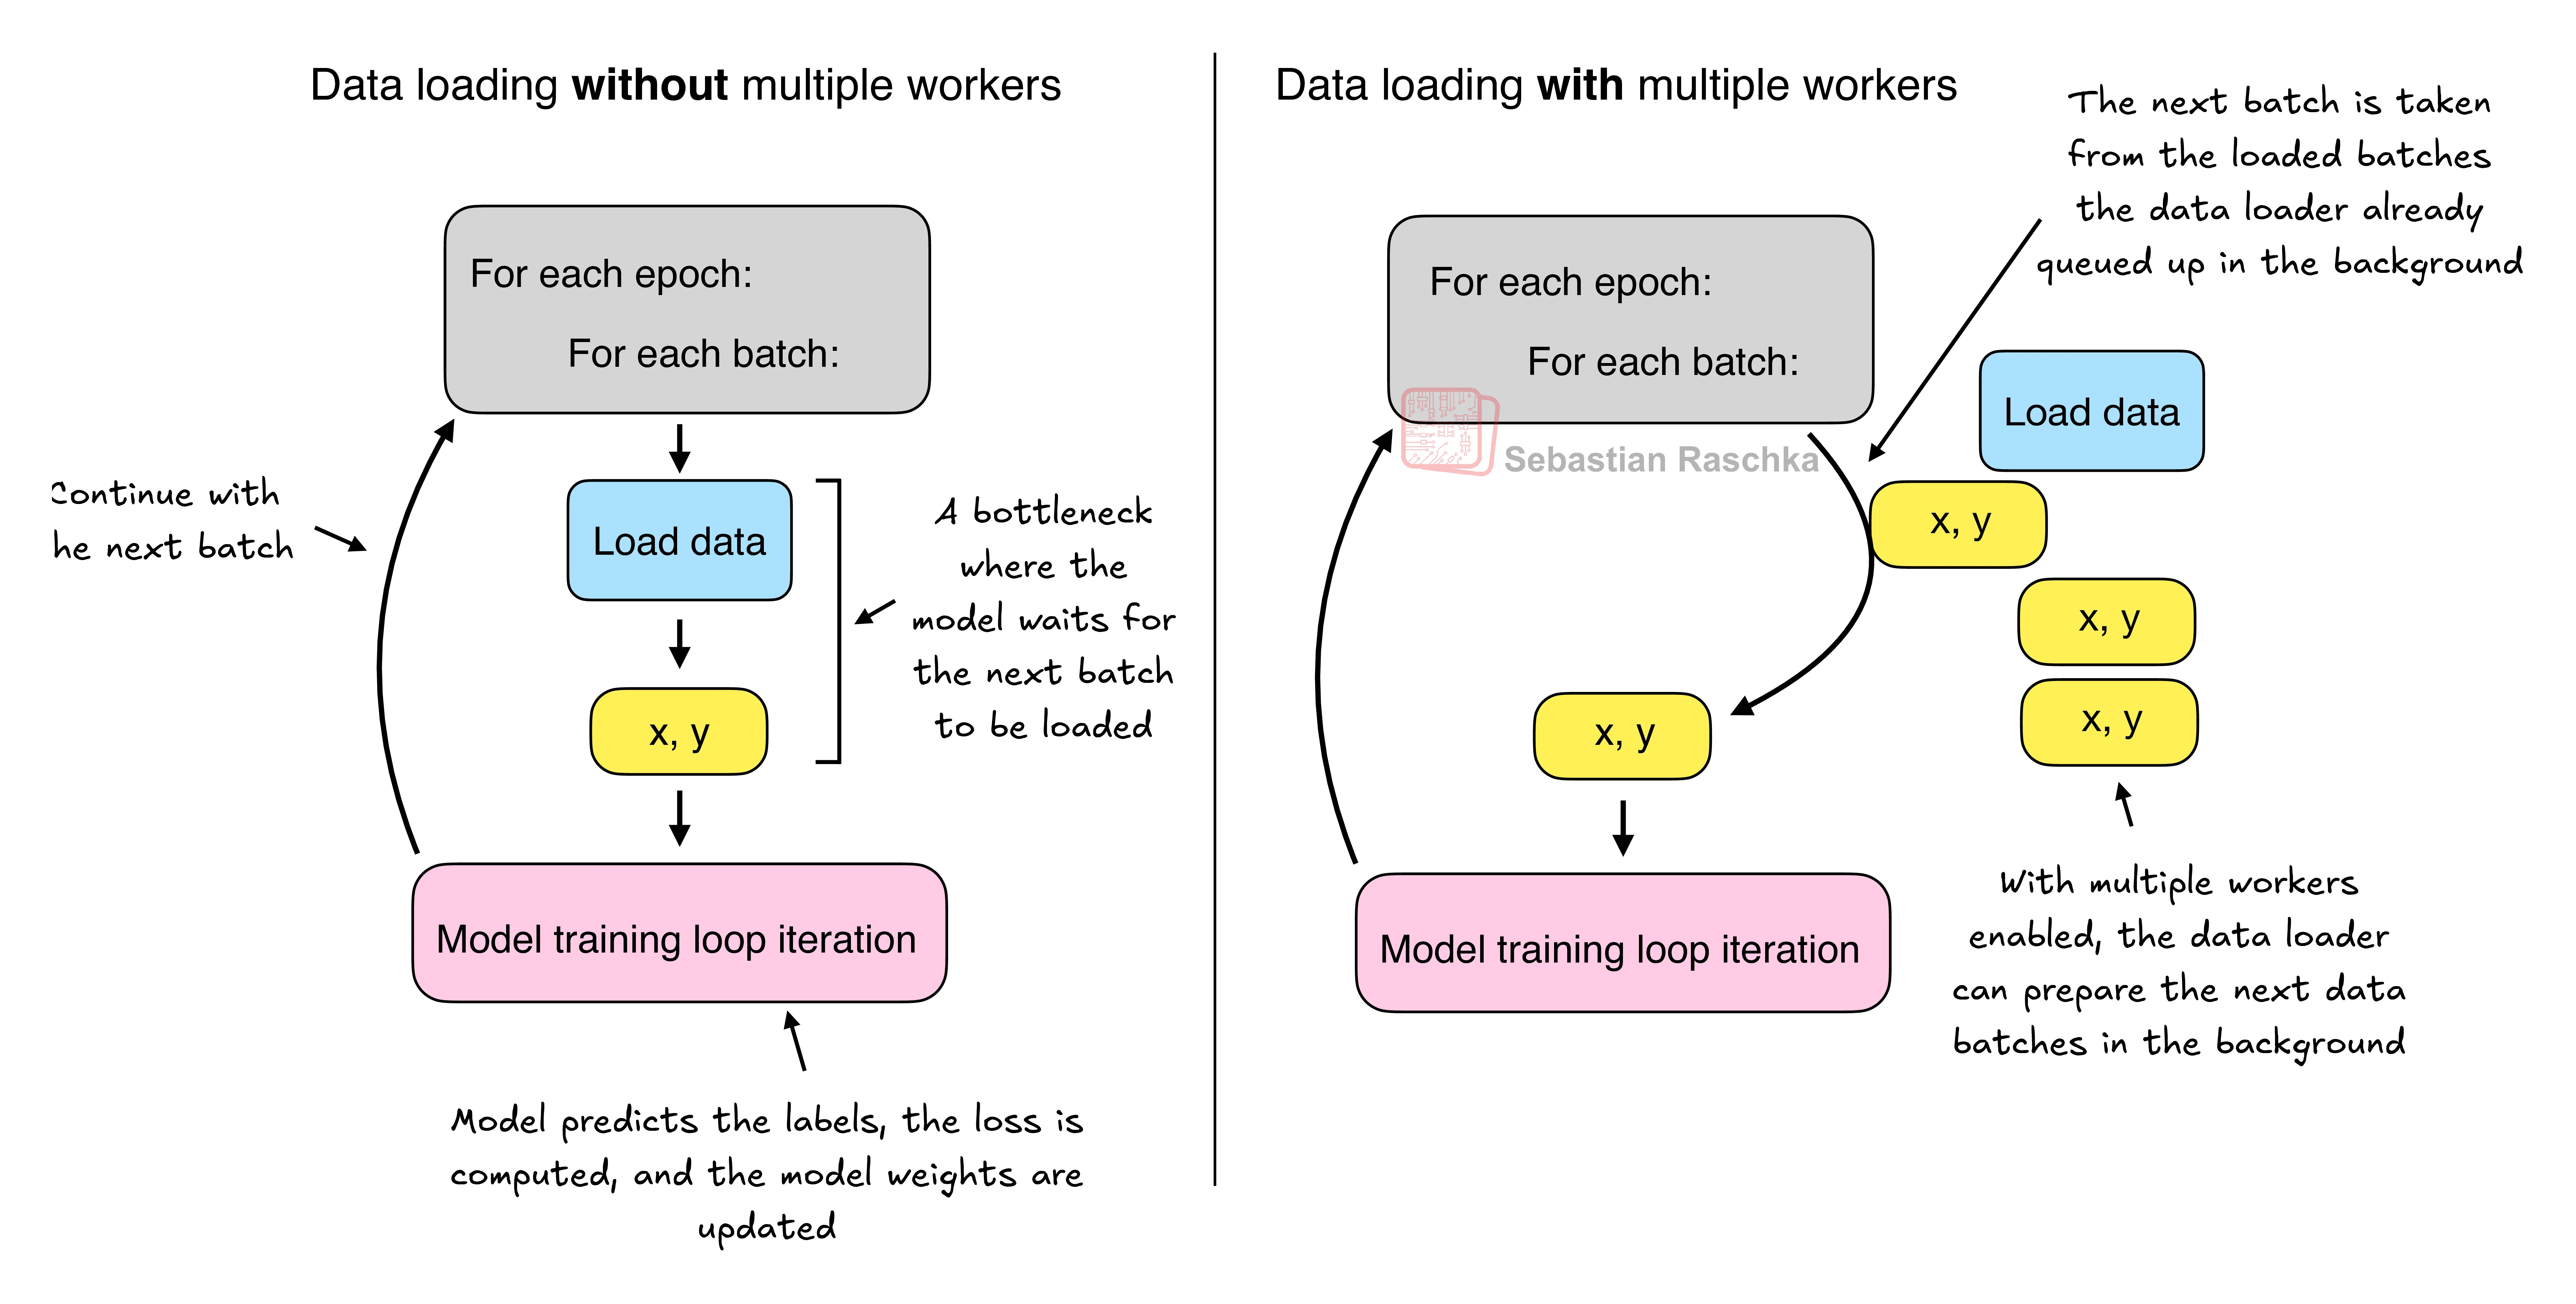

# A typical training loop

In [ ]:
import torch.nn.functional as F


torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        logits = model(features)

        loss = F.cross_entropy(logits, labels) # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()
    # Optional model evaluation

Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


First, note that we initialized a model with two inputs and two outputs. That’s because the toy dataset from the previous section has two input features and two class labels to predict. We used a stochastic gradient descent (SGD) optimizer with a learning rate (lr) of 0.5. The learning rate is a hyperparameter, meaning it’s a tunable setting that we have to experiment with based on observing the loss. Ideally, we want to choose a learning rate such that the loss converges after a certain number of epochs – the number of epochs is another hyperparameter to choose.

In practice, we often use a third dataset, a so-called validation dataset, to find the optimal hyperparameter settings. A validation dataset is similar to a test set. However, while we only want to use a test set precisely once to avoid biasing the evaluation, we usually use the validation set multiple times to tweak the model settings.

We also introduced new settings called model.train() and model.eval(). As these names imply, these settings are used to put the model into a training and an evaluation mode. This is necessary for components that behave differently during training and inference, such as dropout or batch normalization layers. Since we don’t have dropout or other components in our NeuralNetwork class that are affected by these settings, using model.train() and model.eval() is redundant in our code above. However, it’s best practice to include them anyway to avoid unexpected behaviors when we change the model architecture or reuse the code to train a different model.

As discussed earlier, we pass the logits directly into the cross_entropy loss function, which will apply the softmax function internally for efficiency and numerical stability reasons. Then, calling loss.backward() will calculate the gradients in the computation graph that PyTorch constructed in the background. The optimizer.step() method will use the gradients to update the model parameters to minimize the loss. In the case of the SGD optimizer, this means multiplying the gradients with the learning rate and adding the scaled negative gradient to the parameters.

In [ ]:
# After we trained the model, we can use it to make predictions, as shown below:

model.eval()

with torch.no_grad():
    outputs = model(x_train)

print(outputs)

tensor([[ 2.8569, -4.1618],
        [ 2.5382, -3.7548],
        [ 2.0944, -3.1820],
        [-1.4814,  1.4816],
        [-1.7176,  1.7342]])


In [ ]:
# To obtain the class membership probabilities, we can then use PyTorch’s softmax function, as follows:

torch.set_printoptions(sci_mode=False)
probas = torch.softmax(outputs, dim=1)
print(probas)

tensor([[    0.9991,     0.0009],
        [    0.9982,     0.0018],
        [    0.9949,     0.0051],
        [    0.0491,     0.9509],
        [    0.0307,     0.9693]])


In [ ]:
# We can convert these values into class labels predictions using PyTorch’s argmax function,
# which returns the index position of the highest value in each row if we set dim=1
# (setting dim=0 would return the highest value in each column, instead):

predictions = torch.argmax(probas, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [ ]:
# Note that it is unnecessary to compute softmax probabilities to obtain the class labels.
# We could also apply the argmax function to the logits (outputs) directly:

predictions = torch.argmax(outputs, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [ ]:
predictions == y_train


tensor([True, True, True, True, True])

In [ ]:
# Using torch.sum, we can count the number of correct prediction as follows:

torch.sum(predictions == y_train)

tensor(5)

In [ ]:
# To generalize the computation of the prediction accuracy, let’s implement a compute_accuracy function as shown in the following code.
def compute_accuracy(model, dataloader):

    model = model.eval()
    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):

        with torch.no_grad():
            logits = model(features)

        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)

    return (correct / total_examples).item()

Note that the following `compute_accuracy` function iterates over a data loader to compute the number and fraction of the correct predictions. This is because when we work with large datasets, we typically can only call the model on a small part of the dataset due to memory limitations. The `compute_accuracy` function above is a general method that scales to datasets of arbitrary size since, in each iteration, the dataset chunk that the model receives is the same size as the batch size seen during training.

In [ ]:
# We can then apply the function to the training as follows:

print(compute_accuracy(model, train_loader))

#Similarly, we can apply the function to the test set as follows:

print(compute_accuracy(model, test_loader))

1.0
1.0


# Saving and loading models

In [ ]:
# Here’s the recommended way how we can save and load models in PyTorch:

torch.save(model.state_dict(), "model.pth")

The model’s state_dict is a Python dictionary object that maps each layer in the model to its trainable parameters (weights and biases). Note that "model.pth" is an arbitrary filename for the model file saved to disk. We can give it any name and file ending we like; however, .pth and .pt are the most common conventions.

In [ ]:
# Once we saved the model, we can restore it from disk as follows:

model = NeuralNetwork(2, 2) # needs to match the original model exactly
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

The `torch.load("model.pth")` function reads the file `"model.pth"` and reconstructs the Python dictionary object containing the model’s parameters while `model.load_state_dict()` applies these parameters to the model, effectively restoring its learned state from when we saved it.

Note that the line model = NeuralNetwork(2, 2) above is not strictly necessary if you execute this code in the same session where you saved a model. However, I included it here to illustrate that we need an instance of the model in memory to apply the saved parameters. Here, the NeuralNetwork(2, 2) architecture needs to match the original saved model exactly.

# Optimizing training performance with GPUs

## PyTorch computations on GPU devices

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
# Now, suppose we have two tensors that we can add as follows – this computation will be carried out on the CPU by default:

tensor_1 = torch.tensor([1., 2., 3.])
tensor_2 = torch.tensor([4., 5., 6.])

print(tensor_1 + tensor_2)

tensor([5., 7., 9.])


In [ ]:
# We can now use the .to() method to transfer these tensors onto a GPU and perform the addition there:

tensor_1 = tensor_1.to("cuda")
tensor_2 = tensor_2.to("cuda")

print(tensor_1 + tensor_2)

# device='cuda:0', which means that the tensors reside on the first GPU

tensor([5., 7., 9.], device='cuda:0')


In [ ]:
# All tensors must be on the same device. Otherwise, the computation will fail,
# as shown below, where one tensor resides on the CPU and the other on the GPU:

tensor_1 = tensor_1.to("cpu")
print(tensor_1 + tensor_2)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
# All we have to do is transfer the tensors onto the same GPU device, and PyTorch will handle the rest.

## Single-GPU training

In [ ]:
# A typical training loop, to run on a GPU. This requires only changing three lines of code, as shown in the code below

torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)

# New: Define a device variable that defaults to a GPU.
device = torch.device("cuda")
# New: Transfer the model onto the GPU.
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        # New: Transfer the data onto the GPU.
        features, labels = features.to(device), labels.to(device)    #C
        logits = model(features)
        loss = F.cross_entropy(logits, labels) # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()
    # Optional model evaluation

Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


In [ ]:
# We can also use .to("cuda") instead of device = torch.device("cuda").
# Transferring a tensor to "cuda" instead of torch.device("cuda") works as well and is shorter.

torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)


# New: Transfer the model onto the GPU.
model.to("cuda") # <-------

optimizer = torch.optim.SGD(model.parameters(), lr=0.7)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        # New: Transfer the data onto the GPU.
        features, labels = features.to(device), labels.to(device)    #C
        logits = model(features)
        loss = F.cross_entropy(logits, labels) # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()
    # Optional model evaluation

Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.83
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.42
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.16
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.00
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


In [ ]:
# We can also modify the statement to the following, which will make the
# same code executable on a CPU if a GPU is not available, which is usually considered best practice when sharing PyTorch code:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
